## PyTorch

PyTorch is an open-source machine learning framework that is primarily used for developing and training deep learning models. It was developed by Facebook's Al Research Lab and released in 2016. PyTorch provides a flexible and dynamic approach to building neural networks, making it a popular choice among researchers and developers.

The framework is built on a dynamic computational graph concept, which means that the graph is built and modified on-the-fly as the program runs. This allows for more intuitive and flexible model development, as you can use standard Python control flow statements and debug the model easily.

PyTorch supports automatic differentiation, which enables efficient computation of gradients for training neural networks using backpropagation. It provides a rich set of tools and libraries for tasks such as data loading, model building, optimization, and evaluation.

One of the key advantages of PyTorch is its support for GPU acceleration, allowing you to train models on GPUs to significantly speed up computations. It also has a large and active community, which means there are plenty of resources, tutorials, and pre-trained models available.

PyTorch is often compared to TensorFlow, another popular deep learning framework. While TensorFlow focuses more on static computation graphs, PyTorch emphasizes dynamic computation graphs. This fundamental difference in design philosophy gives PyTorch an edge when it comes to flexibility and ease of use.

Overall, PyTorch is widely used in the research community and is gaining popularity in industry applications as well. It provides a powerful and user-friendly platform for building and training deep learning models.

In [1]:
import torch

In [2]:
t1=torch.tensor(4.)
t1

tensor(4.)

In [3]:
type(t1)

torch.Tensor

In [4]:
t1.dtype

torch.float32

In [5]:
# vector
t2=torch.tensor([1,2,3,4])
T3=torch.tensor([1.,2,3,4])
print(t2,T3)

tensor([1, 2, 3, 4]) tensor([1., 2., 3., 4.])


In [6]:
# matrix
t3=torch.tensor([
    [2., 3],
    [4, 5],
    [6, 7]
])
t3.dtype

torch.float32

In [7]:
# 3D array
t4=torch.tensor([
  [
      [1,2,3,4],
      [2,3,4,5]
  ],
  [
      [4,5,6,7],
      [6,7,8,9]
  ]
])
t4

tensor([[[1, 2, 3, 4],
         [2, 3, 4, 5]],

        [[4, 5, 6, 7],
         [6, 7, 8, 9]]])

In [8]:
t4.dtype

torch.int64

In [9]:
print(t4.shape)

torch.Size([2, 2, 4])


### Tensor operation and gradient

In [10]:
# create tensors

x=torch.tensor(3.)
w=torch.tensor(3., requires_grad=True)
b=torch.tensor(5., requires_grad=True)

x, w, b

(tensor(3.), tensor(3., requires_grad=True), tensor(5., requires_grad=True))

In [11]:
# arithmatic operation

y= w*x+ b
y

tensor(14., grad_fn=<AddBackward0>)

In [12]:
# compute devivative
y.backward()

In [13]:
# display values

print('dy/dx', x.grad)
print('dy/dw', w.grad)
print('dy/db', b.grad)

dy/dx None
dy/dw tensor(3.)
dy/db tensor(1.)


**Tensor functions**

In [14]:
# create a function with a fixed value for every elements

t5=torch.full((3,2), 7)
t5

tensor([[7, 7],
        [7, 7],
        [7, 7]])

In [15]:
# concat
t6= torch.cat((t3, t5))
t6

tensor([[2., 3.],
        [4., 5.],
        [6., 7.],
        [7., 7.],
        [7., 7.],
        [7., 7.]])

In [16]:
# sine of elements
t7=torch.sin(t6)
t7

tensor([[ 0.9093,  0.1411],
        [-0.7568, -0.9589],
        [-0.2794,  0.6570],
        [ 0.6570,  0.6570],
        [ 0.6570,  0.6570],
        [ 0.6570,  0.6570]])

In [17]:
# change the shape of a tensor

t8=t7.reshape(3,2,2)
t8

tensor([[[ 0.9093,  0.1411],
         [-0.7568, -0.9589]],

        [[-0.2794,  0.6570],
         [ 0.6570,  0.6570]],

        [[ 0.6570,  0.6570],
         [ 0.6570,  0.6570]]])

### interoperability with numpy

In [18]:
import numpy as np
x=np.array([[1,2,3,4], [5,6,7,8]])
x

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [19]:
y=torch.from_numpy(x)
type(y)

torch.Tensor

**Linear classification from scratch using pytorch**

In [20]:
# making training data
# input --> ( temp, rainfall, humidity) ---> yield of apple or orange crops


**Fashion EMNIST neural network example with pytorch**

In [21]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt


In [22]:
training_data=datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)
testing_data=datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

In [23]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [24]:
batch_size=64

# create data loader
train_dataloader=DataLoader(training_data, batch_size=batch_size)
test_dataloader=DataLoader(testing_data, batch_size=batch_size)

for X, y in test_dataloader:
  print('Shape of X[N, C, H, W]', X.shape)
  print('Shape of y', y.shape, y.dtype)
  break

Shape of X[N, C, H, W] torch.Size([64, 1, 28, 28])
Shape of y torch.Size([64]) torch.int64


In [25]:
# get cpu or gpu device for training

device= 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [26]:
# define nn model

class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten=nn.Flatten()

    # hidden layer with relu activation function
    self.linear_relu_stack=nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10)  #output layer
    )

  def forward(self, x):
    x=self.flatten(x)
    logits=self.linear_relu_stack(x)
    return logits

model=NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [27]:
# cross entropy loss ---> bcz it is a multiclass classification problem

loss_fn=nn.CrossEntropyLoss()

# optimizer---> SGD---> strocastic gradient descent
# lr= learning rate
optimizer=torch.optim.SGD(model.parameters(), lr=1e-3)

In [28]:

def train(dataloader, model, loss_fn, optimizer):
  size=len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device)

    # compute prediction error
    pred=model(X)
    loss=loss_fn(pred, y)

    # backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current=loss.item(), batch * len(X)
      print(f"Loss: {loss} [{current}/{size}]")

In [29]:
def test(dataloader, model, loss_fn):
  size=len(dataloader.dataset)
  num_batch=len(dataloader)
  model.eval()

  test_loss, correct=0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y=X.to(device), y.to(device)
      pred=model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batch # average loss per batch
  correct /= size # % of correct prediction or accuracy

  print(f"Test error: \n Accuracy: {100*correct} %, Avg loss per batch: {test_loss}\n")

In [30]:
# for batch, (X, y) in enumerate(train_dataloader):
#   X, y= X.to(device), y.to(device)

#     # compute prediction error
#   pred=model(X)
#   print(X.shape)
#   print(y.shape)
#   print(pred)
#   break

In [31]:
epoch=20
for i in range(epoch):
  print(f"Epoch {i+1}\n -------------------------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)

print('Done !')

Epoch 1
 -------------------------------------------
Loss: 2.3053410053253174 [0/60000]
Loss: 2.2896270751953125 [6400/60000]
Loss: 2.2727720737457275 [12800/60000]
Loss: 2.272181987762451 [19200/60000]
Loss: 2.2505764961242676 [25600/60000]
Loss: 2.2332537174224854 [32000/60000]
Loss: 2.2448880672454834 [38400/60000]
Loss: 2.2103638648986816 [44800/60000]
Loss: 2.203542709350586 [51200/60000]
Loss: 2.192750930786133 [57600/60000]
Test error: 
 Accuracy: 44.85 %, Avg loss per batch: 2.1725767129545757

Epoch 2
 -------------------------------------------
Loss: 2.1797947883605957 [0/60000]
Loss: 2.171550750732422 [6400/60000]
Loss: 2.1205291748046875 [12800/60000]
Loss: 2.1404552459716797 [19200/60000]
Loss: 2.0892553329467773 [25600/60000]
Loss: 2.033311128616333 [32000/60000]
Loss: 2.0731587409973145 [38400/60000]
Loss: 1.9894580841064453 [44800/60000]
Loss: 1.9938668012619019 [51200/60000]
Loss: 1.9472763538360596 [57600/60000]
Test error: 
 Accuracy: 50.36000000000001 %, Avg loss pe

In [64]:
# predictions
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y=testing_data[999][0], testing_data[999][1]
x=x.to(device)
with torch.no_grad():
  pred=model(x)
  print(pred)
  predicted, actual= classes[pred[0].argmax(0)], classes[y]
  print(f"predicted: {predicted} Actual: {actual}")

tensor([[-3.3206, -2.7158, -3.4467, -1.7930, -1.8656,  4.6761, -3.1989,  7.5833,
          1.4552,  3.1688]], device='cuda:0')
predicted: Sneaker Actual: Sneaker


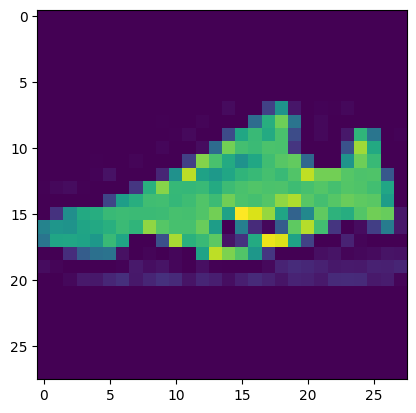

In [65]:
import matplotlib.pyplot as plt
plt.imshow(x.cpu().squeeze())
plt.show()